# Exploratory Data Analysis (EDA)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/data-preprocessing/eda/notes.ipynb)

*Before fitting any model, you look at the data. EDA is the general-purpose toolkit for that — shape and types,
missing values, distributions, outliers, and relationships between columns. Every algorithm module in this repo
assumes you've already done this step; this notebook is where that step actually lives.*


## 1. What EDA is for

A model can only be as good as the data it's fed. EDA is the habit of actually looking before fitting anything —
it answers questions like:

- What does each column actually contain? Is it the type you expect?
- Are there missing values, and if so, how many and where?
- What does each column's distribution look like — skewed, symmetric, full of outliers?
- How do columns relate to each other, and to the target?

Skipping this step doesn't make these problems go away — it just means you discover them later, as a model that
mysteriously underperforms or throws an error deep inside a `.fit()` call.

**The dataset for this notebook:** the Auto MPG dataset — real cars from the 1970s-80s, predicting fuel economy
(`mpg`) from engine specs. Small enough to eyeball, messy enough (real missing values) to be worth cleaning.


## 2. First look: shape, types, and summary statistics

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

MPG_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
MPG_PATH = "data/auto-mpg.csv"

if not os.path.exists(MPG_PATH):
    os.makedirs("data", exist_ok=True)
    pd.read_csv(MPG_URL).to_csv(MPG_PATH, index=False)

df = pd.read_csv(MPG_PATH)
df.shape

(398, 9)

In [2]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

`horsepower` shows up as `float64` here, but it's worth checking *why* a numeric-looking column would ever load
as text in the first place — it's one of the most common real-world data issues, and the next section is about
exactly that.


In [3]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


> **Read `describe()` for shape, not just averages.** Compare `min`/`max`/`mean` — if the mean is far from the
> median-ish center of the range, or `max` is wildly larger than the 75th percentile, that's often your first
> hint of skew or outliers, before you've even plotted anything.


## 3. Detecting and handling missing values

Real datasets almost always have gaps. Sometimes they're proper `NaN`; sometimes — as with the original UCI
version of this dataset — they're hidden behind a placeholder string like `"?"`, which silently turns an entire
numeric column into text (`dtype: object`) until you catch it.


In [4]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

`horsepower` has 6 missing values out of 398 rows. A good first move whenever a numeric-looking column comes in
as `object` dtype is to check for exactly this kind of placeholder:

```python
# if horsepower had loaded as strings, this is how you'd catch a placeholder like "?"
non_numeric = df[~df['horsepower'].astype(str).str.replace('.', '', 1).str.isdigit()]
```

### 3.1 Dropping vs. imputing

- **Dropping** the 6 rows is simple, but throws away real data — fine when missingness is rare and the dataset
  is large; risky when it isn't.
- **Imputing** fills the gap with a value derived from the rest of the column. The two common choices:

| Strategy | Formula | When to use |
|---|---|---|
| Mean | average of non-missing values | Roughly symmetric distribution, no major outliers |
| Median | middle value of non-missing values | Skewed distribution or outliers — the mean gets pulled toward them, the median doesn't |


In [5]:
mean_hp = df['horsepower'].mean()
median_hp = df['horsepower'].median()
print(f"Mean horsepower:   {mean_hp:.2f}")
print(f"Median horsepower: {median_hp:.2f}")

df_imputed = df.copy()
df_imputed['horsepower'] = df_imputed['horsepower'].fillna(median_hp)
df_imputed['horsepower'].isna().sum()

Mean horsepower:   104.47
Median horsepower: 93.50


np.int64(0)

> **Default to the median** unless you have a specific reason to prefer the mean — it's the more robust choice
> when you haven't yet checked the column's distribution for skew or outliers (which is exactly what the next
> two sections do).


## 4. Understanding distributions

A histogram answers questions a table of numbers can't at a glance: is this column roughly bell-shaped, skewed
to one side, or multi-modal (several distinct clusters)?


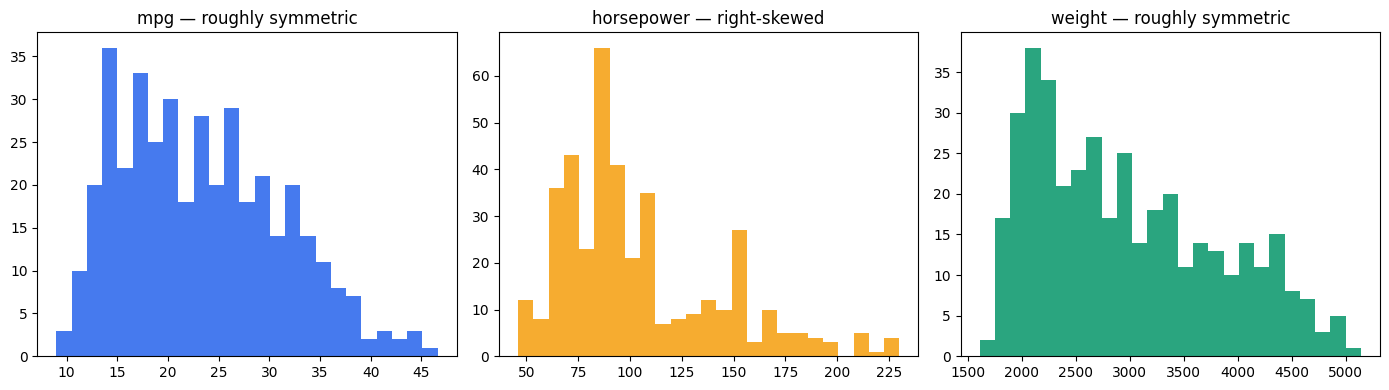

mpg skew:        0.46
horsepower skew: 1.11


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df_imputed['mpg'], bins=25, color="#2563EB", alpha=0.85)
axes[0].set_title("mpg — roughly symmetric")

axes[1].hist(df_imputed['horsepower'], bins=25, color="#F59E0B", alpha=0.85)
axes[1].set_title("horsepower — right-skewed")

axes[2].hist(df_imputed['weight'], bins=25, color="#059669", alpha=0.85)
axes[2].set_title("weight — roughly symmetric")

plt.tight_layout()
plt.show()

print(f"mpg skew:        {df_imputed['mpg'].skew():.2f}")
print(f"horsepower skew: {df_imputed['horsepower'].skew():.2f}")

`horsepower`'s positive skew (a long tail toward high values) is exactly the kind of shape where the mean and
median diverge — a good sanity check for the imputation choice made above.


## 5. Detecting outliers

An outlier is a value far enough from the rest of the data that it's worth a second look — it might be a data
entry error, a genuinely rare case, or a sign the column needs a transform. Two standard, general-purpose ways
to flag candidates:

### 5.1 The IQR rule

$$
\text{IQR} = Q_3 - Q_1 \qquad \text{outlier if } x < Q_1 - 1.5 \cdot \text{IQR} \ \text{ or } \ x > Q_3 + 1.5 \cdot \text{IQR}
$$


IQR bounds: [2.5, 198.5]
Outliers flagged: 11


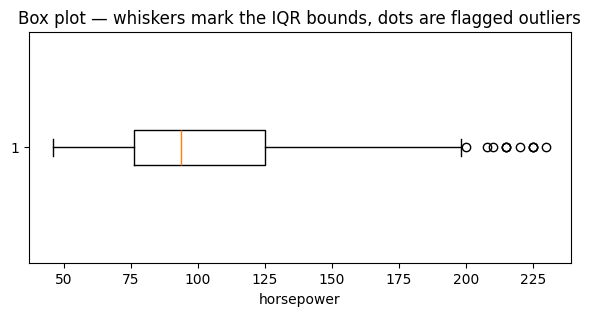

In [7]:
q1, q3 = df_imputed['horsepower'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers_iqr = df_imputed[(df_imputed['horsepower'] < lower) | (df_imputed['horsepower'] > upper)]
print(f"IQR bounds: [{lower:.1f}, {upper:.1f}]")
print(f"Outliers flagged: {len(outliers_iqr)}")

plt.figure(figsize=(7, 3))
plt.boxplot(df_imputed['horsepower'], vert=False)
plt.title("Box plot — whiskers mark the IQR bounds, dots are flagged outliers")
plt.xlabel("horsepower")
plt.show()

### 5.2 The Z-score rule

$$
z = \frac{x - \mu}{\sigma} \qquad \text{outlier if } |z| > 3 \text{ (a common threshold)}
$$


In [8]:
z_scores = (df_imputed['horsepower'] - df_imputed['horsepower'].mean()) / df_imputed['horsepower'].std()
outliers_z = df_imputed[z_scores.abs() > 3]
print(f"Outliers flagged: {len(outliers_z)}")

Outliers flagged: 5


> **IQR vs. Z-score:** IQR doesn't assume any particular distribution shape, which makes it the safer default
> for skewed data like `horsepower` above. Z-score assumes a roughly normal distribution — on skewed data it can
> under- or over-flag outliers, since the mean and standard deviation it's built from are themselves pulled by
> the skew.

**What to do once you've found them** depends on the situation: drop genuine data-entry errors, cap extreme
values at a threshold (winsorizing), or leave them if they're real and the model you're using is meant to
handle them. There's no universal answer — that judgment call is part of EDA, not something a formula settles
for you.


## 6. Checking relationships between columns

A correlation matrix is a fast way to see which numeric features move together — useful both for understanding
the data and for spotting redundant features before they become a multicollinearity problem downstream.


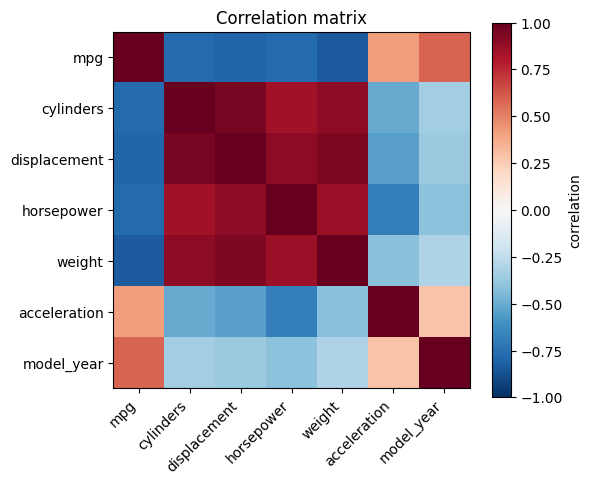

In [9]:
numeric_cols = df_imputed.select_dtypes(include=[np.number])
corr = numeric_cols.corr()

plt.figure(figsize=(6, 5))
im = plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, label="correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

`displacement`, `cylinders`, `weight`, and `horsepower` are all strongly correlated with each other here — cars
with bigger engines tend to be heavier and more powerful, unsurprisingly. That's worth remembering: strongly
correlated *features* are a multicollinearity risk once you get to modeling, even before you've touched a
target variable at all.


## 7. Summary — the EDA checklist

- **Shape & types** — `df.shape`, `df.dtypes`. Catch numeric columns that loaded as text (usually a placeholder
  like `"?"` hiding in there).
- **Missing values** — `df.isna().sum()`. Decide drop vs. impute; default to median imputation unless you have a
  specific reason for the mean.
- **Distributions** — histograms + `.skew()`. Skewed columns change which imputation/scaling choices make sense.
- **Outliers** — IQR rule (robust, distribution-agnostic) or Z-score (assumes roughly normal data). Decide
  drop / cap / keep based on whether they're errors or genuine extreme cases.
- **Relationships** — a correlation matrix flags redundant features early, before they turn into a
  multicollinearity problem in a model.

**Where this leads next:** once the data is understood and cleaned, [Feature Scaling](../feature-scaling/notes.ipynb)
and [Encoding Categorical Features](../encoding/notes.ipynb) cover the two remaining preprocessing steps most
models need before they can be fit at all.
